## Трогаем датасет

На примере [Popular Sneakers Classification](https://www.kaggle.com/datasets/nikolasgegenava/sneakers-classification?resource=download)

In [3]:
import sys

sys.path.append('../..')

%load_ext autoreload
%autoreload 2

In [7]:
from src.data.utils.eda_utils import directory_to_dataframe

path_to_dataset = "../../data/01_raw/sneakers-dataset"
df = directory_to_dataframe(path_to_dataset)
df

,path,sneaker_class
0,reebok_classic_leather/0071.jpg,reebok_classic_leather
1,reebok_classic_leather/0065.jpg,reebok_classic_leather
2,reebok_classic_leather/0059.jpg,reebok_classic_leather
3,reebok_classic_leather/0058.jpg,reebok_classic_leather
4,reebok_classic_leather/0064.jpg,reebok_classic_leather
...,...,...
5948,nike_air_max_97/0083.jpg,nike_air_max_97
5949,nike_air_max_97/0097.jpg,nike_air_max_97
5950,nike_air_max_97/0040.jpg,nike_air_max_97
5951,nike_air_max_97/0054.jpg,nike_air_max_97


In [8]:
df.query('sneaker_class == "yeezy_slide"')

,path,sneaker_class
1796,yeezy_slide/0071.jpg,yeezy_slide
1797,yeezy_slide/0065.jpg,yeezy_slide
1798,yeezy_slide/0059.jpg,yeezy_slide
1799,yeezy_slide/0105.jpg,yeezy_slide
1800,yeezy_slide/0111.jpg,yeezy_slide
...,...,...
1936,yeezy_slide/0083.jpg,yeezy_slide
1937,yeezy_slide/0097.jpg,yeezy_slide
1938,yeezy_slide/0040.jpg,yeezy_slide
1939,yeezy_slide/0054.jpg,yeezy_slide


In [9]:
from src.data.utils.eda_utils import sneaker_class_to_brand

class_to_brand = sneaker_class_to_brand(df["sneaker_class"].unique())

df["brand"] = df["sneaker_class"].map(class_to_brand)
df

,path,sneaker_class,brand
0,reebok_classic_leather/0071.jpg,reebok_classic_leather,reebok
1,reebok_classic_leather/0065.jpg,reebok_classic_leather,reebok
2,reebok_classic_leather/0059.jpg,reebok_classic_leather,reebok
3,reebok_classic_leather/0058.jpg,reebok_classic_leather,reebok
4,reebok_classic_leather/0064.jpg,reebok_classic_leather,reebok
...,...,...,...
5948,nike_air_max_97/0083.jpg,nike_air_max_97,nike
5949,nike_air_max_97/0097.jpg,nike_air_max_97,nike
5950,nike_air_max_97/0040.jpg,nike_air_max_97,nike
5951,nike_air_max_97/0054.jpg,nike_air_max_97,nike


In [10]:
df.groupby("brand").path.count().sort_values(ascending=False)

brand
nike           2295
adidas          950
new_balance     653
converse        544
vans            478
yeezy           401
reebok          246
puma            148
salomon         147
asics            91
Name: path, dtype: int64

In [11]:
from src.data.utils.eda_utils import add_image_dimensions

df = add_image_dimensions(df, path_to_dataset)

In [12]:
from src.data.utils.background_analysis import add_background_analysis_to_dataframe

df = add_background_analysis_to_dataframe(df, path_to_dataset, border_margin=0.05)

In [13]:
df["resolution"] = df["width"] * df["height"]
df.describe()

,width,height,background_uniformity,resolution
count,5953.000000,5953.000000,5953.000000,5953.000000
mean,138.456912,128.475223,0.333162,17501.932135
std,22.619928,18.591763,0.369917,2423.368490
min,49.000000,40.000000,0.007809,6480.000000
25%,117.000000,115.000000,0.023048,15680.000000
50%,140.000000,140.000000,0.098503,18306.000000
75%,162.000000,140.000000,0.654592,19600.000000
max,300.000000,140.000000,1.000000,22540.000000


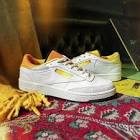

reebok_club_c_85/0025.jpg


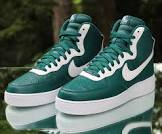

nike_air_force_1_high/0004.jpg


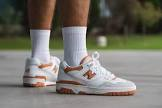

new_balance_550/0085.jpg


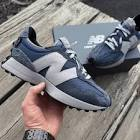

new_balance_327/0035.jpg


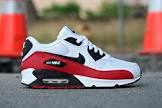

nike_air_max_90/0105.jpg


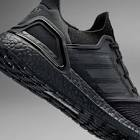

adidas_ultraboost/0107.jpg


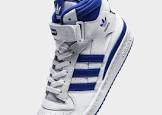

adidas_forum_high/0147.jpg


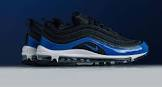

nike_air_max_97/0092.jpg


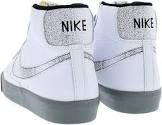

nike_blazer_mid_77/0023.jpg


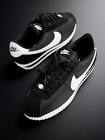

nike_cortez/0120.jpg


In [14]:
from PIL import Image
from IPython.display import display
import os

sub_df = df.query("background_uniformity < 0.023").sample(10, random_state=42)
for path in sub_df["path"]:
    with Image.open(os.path.join(path_to_dataset, path)) as img:
        display(img)
        print(f"{path}")

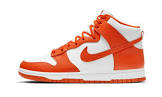

nike_dunk_high/0135.jpg


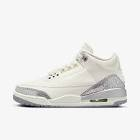

nike_air_jordan_3/0001.jpg


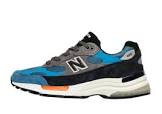

new_balance_992/0029.jpg


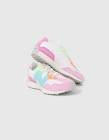

new_balance_327/0063.jpg


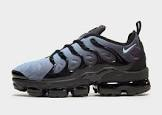

nike_air_vapormax_plus/0093.jpg


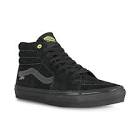

vans_sk8-hi/0076.jpg


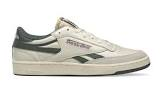

reebok_club_c_85/0121.jpg


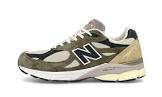

new_balance_990/0068.jpg


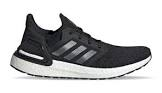

adidas_ultraboost/0078.jpg


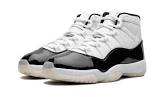

nike_air_jordan_11/0053.jpg


In [15]:
sub_df = df.query("background_uniformity > 0.65").sample(10, random_state=42)
for path in sub_df["path"]:
    with Image.open(os.path.join(path_to_dataset, path)) as img:
        display(img)
        print(f"{path}")

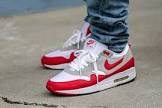

nike_air_max_1/0037.jpg


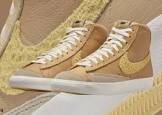

nike_blazer_mid_77/0002.jpg


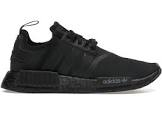

adidas_nmd_r1/0059.jpg


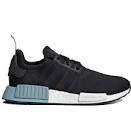

adidas_nmd_r1/0032.jpg


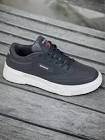

reebok_club_c_85/0080.jpg


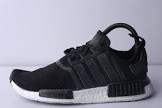

adidas_nmd_r1/0041.jpg


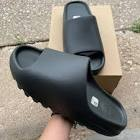

yeezy_slide/0066.jpg


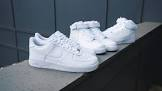

nike_air_force_1_mid/0003.jpg


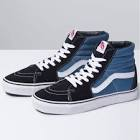

vans_sk8-hi/0061.jpg


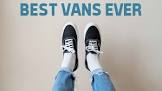

vans_authentic/0011.jpg


In [16]:
thresh = 0.03
sub_df = df.query(
    f"background_uniformity > {thresh} & background_uniformity < {thresh + 0.01}"
).sample(10, random_state=42)
for path in sub_df["path"]:
    with Image.open(os.path.join(path_to_dataset, path)) as img:
        display(img)
        print(f"{path}")

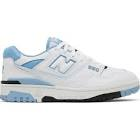

new_balance_550/0120.jpg


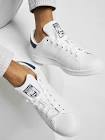

adidas_stan_smith/0004.jpg


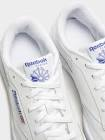

reebok_club_c_85/0019.jpg


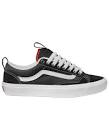

vans_old_skool/0071.jpg


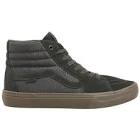

vans_sk8-hi/0107.jpg


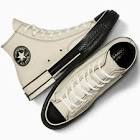

converse_chuck_70_high/0030.jpg


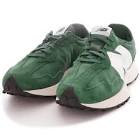

new_balance_327/0038.jpg


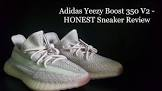

yeezy_boost_350_v2/0006.jpg


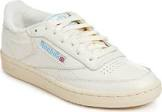

reebok_club_c_85/0094.jpg


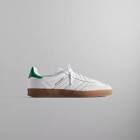

adidas_gazelle/0115.jpg


In [17]:
thresh = 0.04
sub_df = df.query(
    f"background_uniformity > {thresh} & background_uniformity < {thresh + 0.01}"
).sample(10, random_state=42)
for path in sub_df["path"]:
    with Image.open(os.path.join(path_to_dataset, path)) as img:
        display(img)
        print(f"{path}")

In [18]:
df["uniform_flg"] = (df["background_uniformity"] > 0.04).astype(int)
df.describe()

,width,height,background_uniformity,resolution,uniform_flg
count,5953.000000,5953.000000,5953.000000,5953.000000,5953.000000
mean,138.456912,128.475223,0.333162,17501.932135,0.616664
std,22.619928,18.591763,0.369917,2423.368490,0.486240
min,49.000000,40.000000,0.007809,6480.000000,0.000000
25%,117.000000,115.000000,0.023048,15680.000000,0.000000
50%,140.000000,140.000000,0.098503,18306.000000,1.000000
75%,162.000000,140.000000,0.654592,19600.000000,1.000000
max,300.000000,140.000000,1.000000,22540.000000,1.000000


## Битые картинки все одинаковые и имеют бирюзовый цвет

In [19]:
# Фильтруем картинки, на которых есть одновременно бирюзовые, белый и серый цвета

## Цвет кроссовок

Определяем среди изображений с однородным тоном: 
- определяем цвет фона (модальный бакет цвета в рамке)
- определяем модальный бакет цвета по всей картинке (среди всех цветов, кроме цвета фона)
- называем бакет цвета в RGB по-русски: чёрный, жёлтый, красный и т.п.